# Exploratory Data Analysis — CS Students Dataset

The purpose of this EDA is to find meaningful insights about CS students —
their skills, GPA, career interests, and demographics — which will serve us
later for predictive modeling.

We will proceed as follows:

1. **Preparations** — import libraries and load data
2. **Numerical data distribution** — histograms, descriptive stats
3. **Correlation analysis** — which features relate to GPA?
4. **Feature-to-feature relationships** — heatmap
5. **Q → Q** — quantitative vs quantitative (scatter / regression plots)
6. **C → Q** — categorical vs quantitative (boxplots, countplots)

---

## Preparations

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import operator

%matplotlib inline
plt.style.use('bmh')

In [2]:
df = pd.read_csv('cs_students.csv')
df.head()

,Student ID,Name,Gender,Age,GPA,Major,Interested Domain,Projects,Future Career,Python,SQL,Java
0,1,John Smith,Male,21,3.5,Computer Science,Artificial Intelligence,Chatbot Development,Machine Learning Researcher,Strong,Strong,Weak
1,2,Alice Johnson,Female,20,3.2,Computer Science,Data Science,Data Analytics,Data Scientist,Average,Strong,Weak
2,3,Robert Davis,Male,22,3.8,Computer Science,Software Development,E-commerce Website,Software Engineer,Strong,Strong,Average
3,4,Emily Wilson,Female,21,3.7,Computer Science,Web Development,Full-Stack Web App,Web Developer,Weak,Strong,Strong
4,5,Michael Brown,Male,23,3.4,Computer Science,Cybersecurity,Network Security,Information Security Analyst,Average,Weak,Strong


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180 entries, 0 to 179
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Student ID         180 non-null    int64  
 1   Name               180 non-null    object 
 2   Gender             180 non-null    object 
 3   Age                180 non-null    int64  
 4   GPA                180 non-null    float64
 5   Major              180 non-null    object 
 6   Interested Domain  180 non-null    object 
 7   Projects           180 non-null    object 
 8   Future Career      180 non-null    object 
 9   Python             180 non-null    object 
 10  SQL                180 non-null    object 
 11  Java               180 non-null    object 
dtypes: float64(1), int64(2), object(9)
memory usage: 17.0+ KB


The dataset has **180 rows** and **12 columns**. No missing values.

The skill columns (`Python`, `SQL`, `Java`) are stored as text (`Weak / Average / Strong`).
We encode them as integers (`1 / 2 / 3`) so they can be used in numerical analysis.

In [4]:
skill_map  = {'Weak': 1, 'Average': 2, 'Strong': 3}
skill_cols = ['Python', 'SQL', 'Java']

for col in skill_cols:
    df[col] = df[col].map(skill_map)

# Add a composite Skill Score
df['Skill Score'] = df[['Python', 'SQL', 'Java']].mean(axis=1).round(2)

print('Encoding complete. Sample:')
df[['Name', 'Python', 'SQL', 'Java', 'Skill Score']].head(5)

Encoding complete. Sample:


,Name,Python,SQL,Java,Skill Score
0,John Smith,3,3,1,2.33
1,Alice Johnson,2,3,1,2.00
2,Robert Davis,3,3,2,2.67
3,Emily Wilson,1,3,3,2.33
4,Michael Brown,2,1,3,2.00


---

## Numerical Data Distribution

Let's look at the distribution of all numerical features.
We isolate numeric columns and plot their histograms.

In [5]:
print('Descriptive statistics:')
df.describe()

Descriptive statistics:


,Student ID,Age,GPA,Python,SQL,Java,Skill Score
count,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000
mean,90.500000,22.116667,3.615000,2.033333,2.211111,2.027778,2.090833
std,52.105662,2.823040,0.177341,0.864573,0.790932,0.861534,0.230803
min,1.000000,20.000000,3.200000,1.000000,1.000000,1.000000,1.670000
25%,45.750000,21.000000,3.500000,1.000000,2.000000,1.000000,2.000000
50%,90.500000,22.000000,3.600000,2.000000,2.000000,2.000000,2.000000
75%,135.250000,22.250000,3.700000,3.000000,3.000000,3.000000,2.000000
max,180.000000,37.000000,3.900000,3.000000,3.000000,3.000000,2.670000


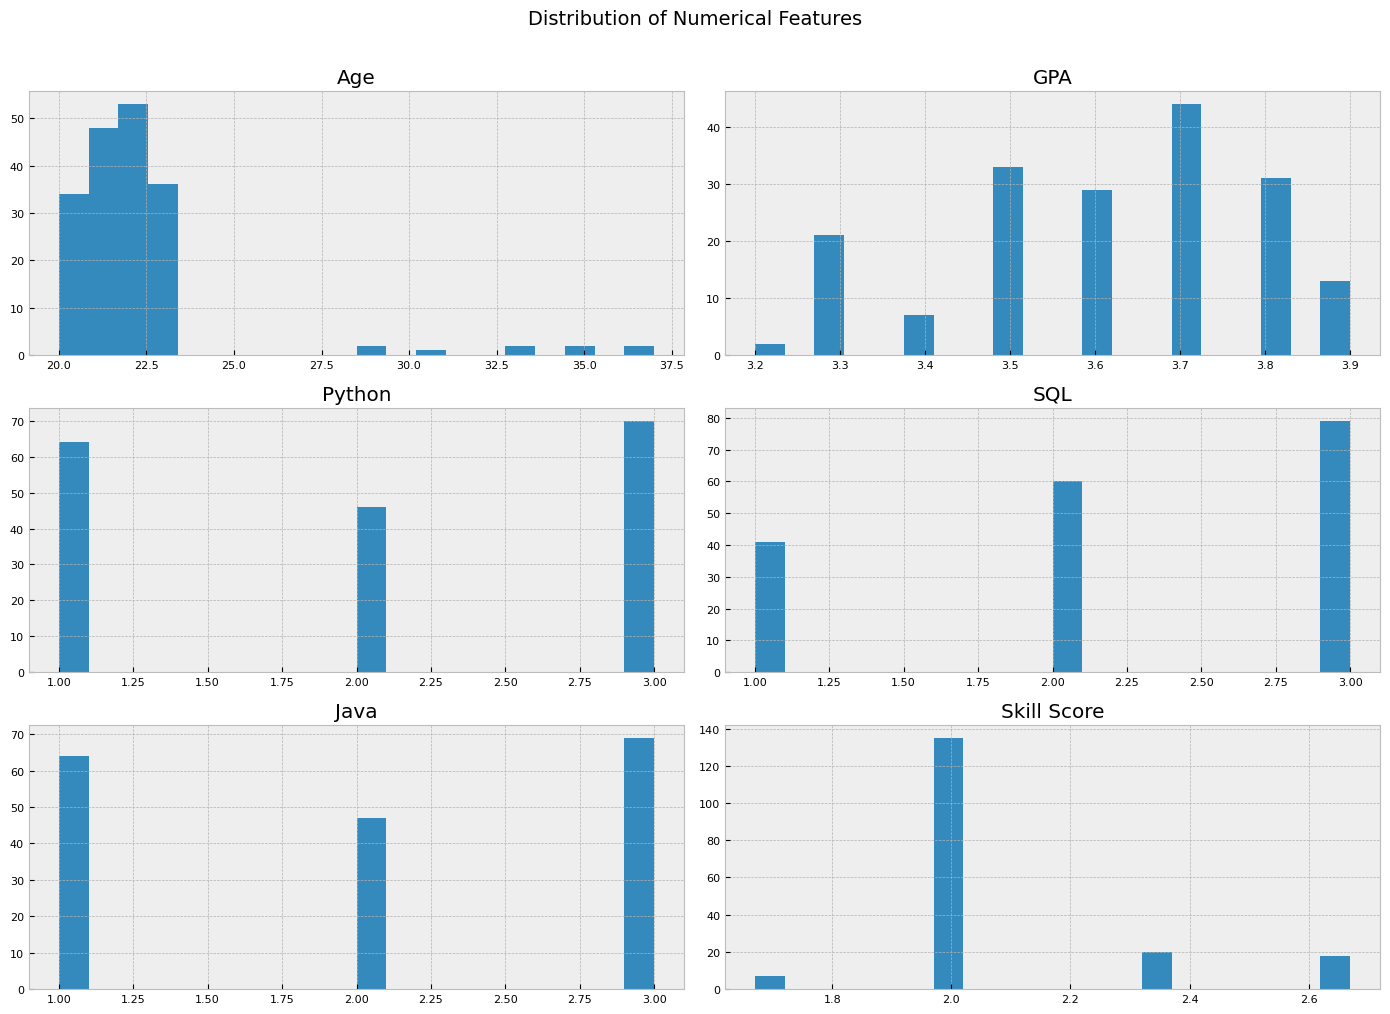

In [6]:
df_num = df.select_dtypes(include=['float64', 'int64']).drop(columns=['Student ID'])
df_num.hist(figsize=(14, 10), bins=20, xlabelsize=8, ylabelsize=8);
plt.suptitle('Distribution of Numerical Features', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

**Observations:**
- `GPA` is narrowly distributed between 3.2 and 3.9, with most students clustered around 3.5–3.7.
- `Age` is mostly concentrated between 20–23 with a few outliers above 29 — likely data entry errors or non-traditional students.
- `Python`, `SQL`, `Java` (1=Weak, 2=Average, 3=Strong) each show a roughly balanced spread, with `SQL` skewing slightly towards Strong.
- `Skill Score` is roughly normally distributed around 2.0.

### GPA Distribution

Since `GPA` is our main outcome variable of interest, let's look at it more closely.

count    180.000000
mean       3.615000
std        0.177341
min        3.200000
25%        3.500000
50%        3.600000
75%        3.700000
max        3.900000
Name: GPA, dtype: float64


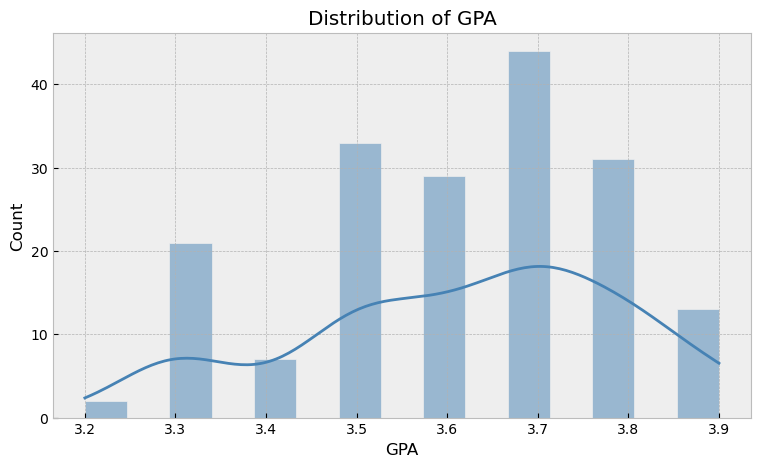

In [7]:
print(df['GPA'].describe())
plt.figure(figsize=(9, 5))
sns.histplot(df['GPA'], bins=15, color='steelblue', kde=True)
plt.title('Distribution of GPA')
plt.xlabel('GPA')
plt.ylabel('Count')
plt.show()

GPA is slightly left-skewed — most students perform well, with fewer students at the lower end.

---

## Correlation Analysis

Now we'll find which numerical features are most correlated with **GPA**.
We store the strongly correlated ones (|r| > 0.2) in `golden_features_list`.

In [8]:
df_num_corr = df_num.corr()['GPA'].drop('GPA')
golden_features_list = df_num_corr[abs(df_num_corr) > 0.15].sort_values(ascending=False)
print(f'Features correlated with GPA (|r| > 0.15):\n{golden_features_list}')

Features correlated with GPA (|r| > 0.15):
Python         0.244489
Skill Score    0.218211
Age            0.202925
SQL            0.168477
Java          -0.225789
Name: GPA, dtype: float64


**Note:** Correlations are moderate in this dataset — GPA is influenced by many factors beyond just skill level or age.
Let's also compute correlations excluding any rows with skill value = 0 (not applicable here, but good practice).

In [9]:
individual_features_df = []
for i in range(len(df_num.columns) - 1):  # exclude GPA itself
    col_name = df_num.columns[i]
    if col_name == 'GPA':
        continue
    tmpDf = df_num[[col_name, 'GPA']]
    tmpDf = tmpDf[tmpDf[col_name] != 0]
    individual_features_df.append(tmpDf)

all_correlations = {f.columns[0]: f.corr()['GPA'][0] for f in individual_features_df}
all_correlations = sorted(all_correlations.items(), key=operator.itemgetter(1))
for key, value in all_correlations:
    print(f'{key:>15}: {value:>10.4f}')

           Java:    -0.2258
            SQL:     0.1685
            Age:     0.2029
         Python:     0.2445


C:\Users\DELL\AppData\Local\Temp\ipykernel_16316\909256251.py:10: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  all_correlations = {f.columns[0]: f.corr()['GPA'][0] for f in individual_features_df}


### Conclusion — Correlation

- **Python** and **Skill Score** have the strongest positive correlation with GPA — students who are better at Python tend to have higher GPAs.
- **Java** has a negative correlation with GPA — high Java skill alone is not associated with high GPA.
- **Age** and **SQL** show very weak correlations.

---

## Feature-to-Feature Relationships

Let's examine how the numerical features relate to **each other**, not just to GPA.
We plot a heatmap of correlations where |r| ≥ 0.15.

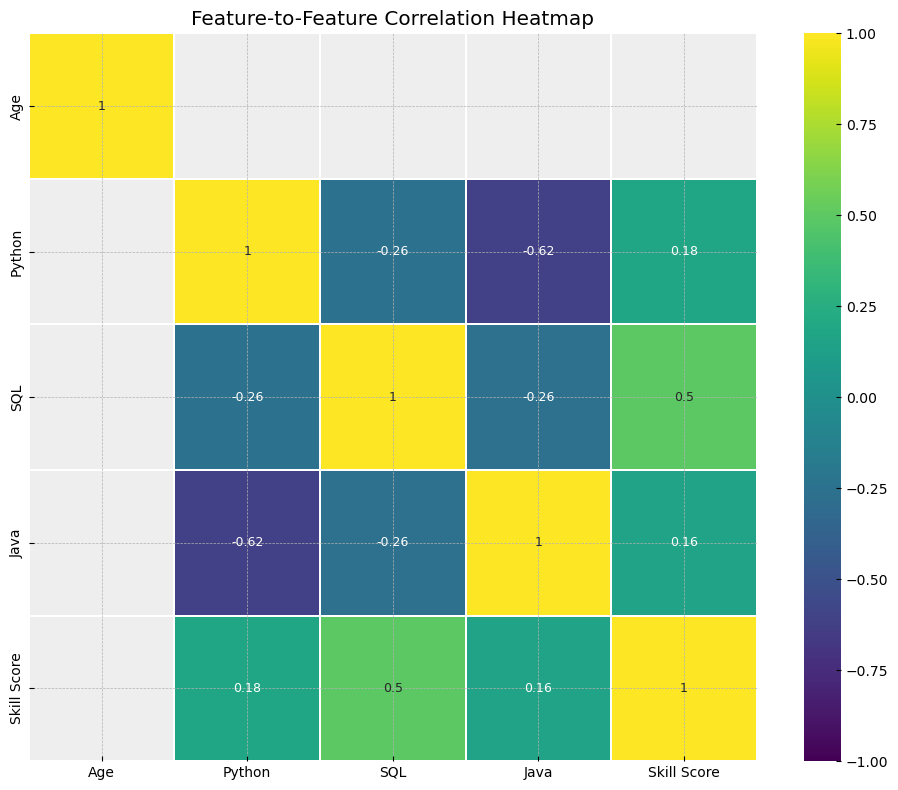

In [10]:
corr = df_num.drop('GPA', axis=1).corr()
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr[(corr >= 0.15) | (corr <= -0.15)],
    cmap='viridis', vmax=1.0, vmin=-1.0,
    linewidths=0.1, annot=True, annot_kws={'size': 9}, square=True
)
plt.title('Feature-to-Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

**Observations:**
- `Python` and `Java` are **strongly negatively correlated** — students who excel at Python tend to be weaker in Java, and vice versa. This suggests students specialize rather than master both equally.
- `SQL` has a mild negative correlation with both `Python` and `Java`.
- `Age` and skill columns show very weak relationships — age alone doesn't determine skill level.

---

## Q → Q: Quantitative to Quantitative

We now plot the correlated quantitative features against **GPA** using regression plots
to visually confirm and explore the relationships.

In [11]:
features_to_analyse = [key for key, value in all_correlations if abs(value) >= 0.15]
features_to_analyse.append('GPA')
print('Features to analyse vs GPA:', features_to_analyse)

Features to analyse vs GPA: ['Java', 'SQL', 'Age', 'Python', 'GPA']


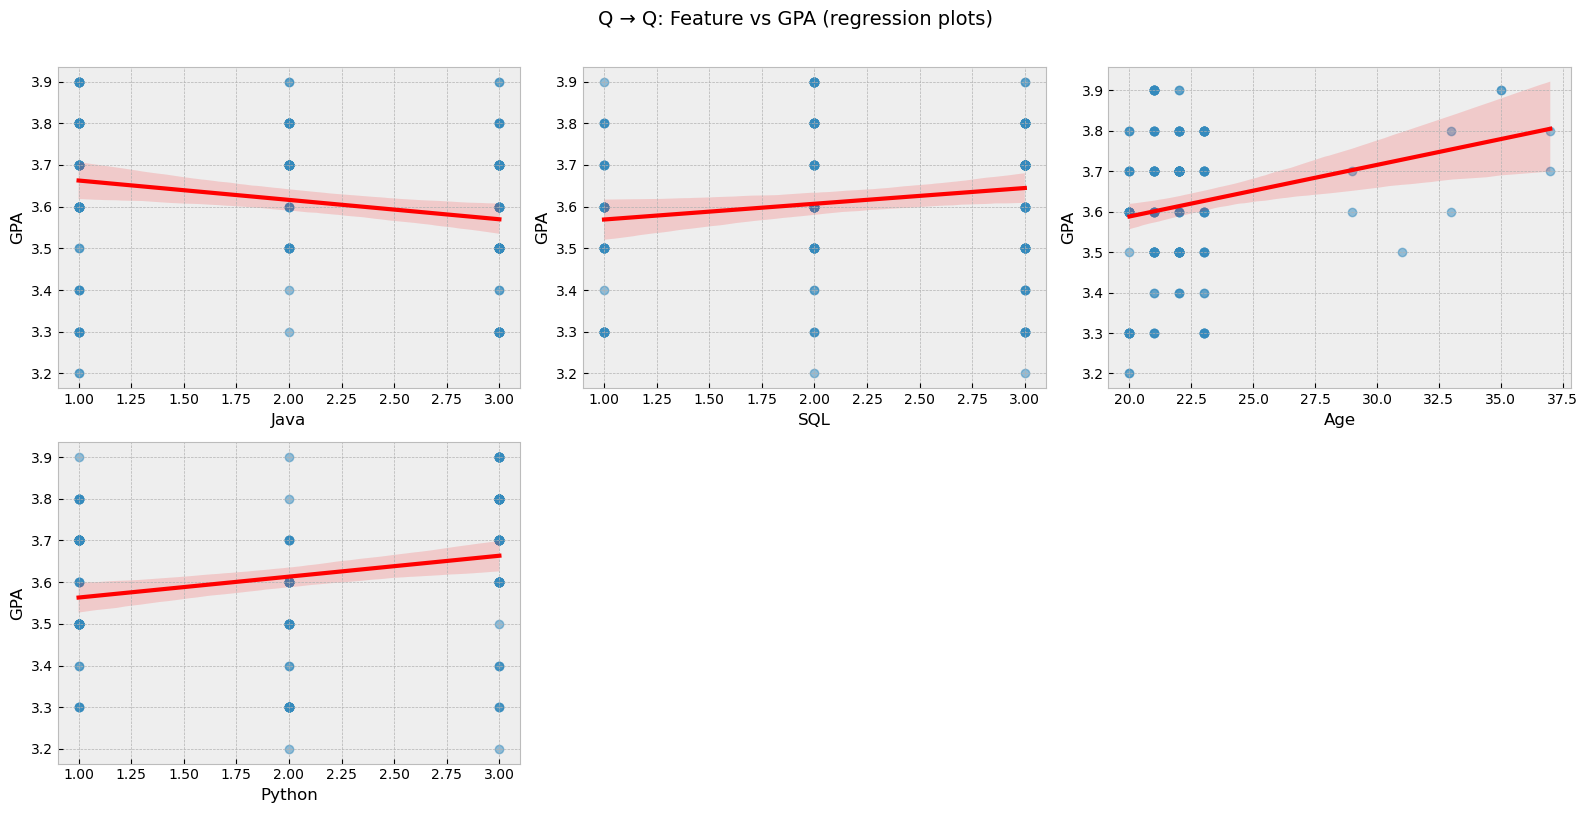

In [12]:
n_features = len(features_to_analyse) - 1
ncols = 3
nrows = -(-n_features // ncols)  # ceiling division

fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 4))

for i, ax in enumerate(fig.axes):
    if i < n_features:
        sns.regplot(
            x=features_to_analyse[i],
            y='GPA',
            data=df[features_to_analyse],
            ax=ax,
            scatter_kws={'alpha': 0.5},
            line_kws={'color': 'red'}
        )
    else:
        ax.set_visible(False)

plt.suptitle('Q → Q: Feature vs GPA (regression plots)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

**Observations:**
- **Python → GPA**: clear positive trend — stronger Python skills associate with higher GPA.
- **Java → GPA**: negative trend — students with high Java scores tend to have slightly lower GPAs.
- **Age → GPA**: a slight upward trend but with high spread and notable outliers at older ages.
- **Skill Score → GPA**: a moderate positive trend, reinforcing that well-rounded students perform better academically.

---

## C → Q: Categorical to Quantitative

We now explore how categorical features (`Gender`, `Interested Domain`, `Future Career`)
relate to the quantitative `GPA`. We use **boxplots** for group comparisons
and **countplots** for frequency distributions.

### GPA by Gender

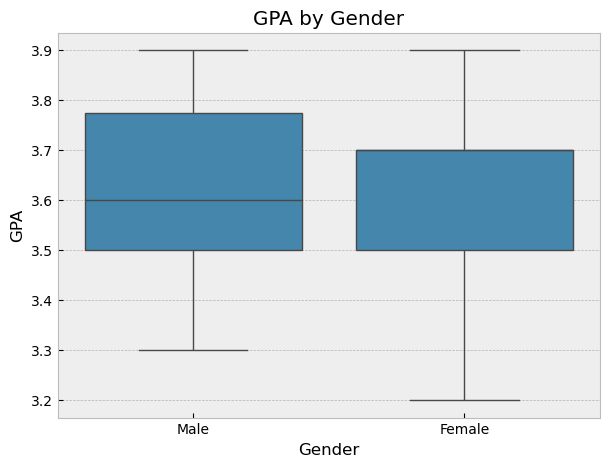

        count      mean       std  min  25%  50%    75%  max
Gender                                                      
Female   78.0  3.628205  0.171999  3.2  3.5  3.7  3.700  3.9
Male    102.0  3.604902  0.181510  3.3  3.5  3.6  3.775  3.9


In [13]:
plt.figure(figsize=(7, 5))
ax = sns.boxplot(x='Gender', y='GPA', data=df)
plt.setp(ax.artists, alpha=0.5, linewidth=2, edgecolor='k')
plt.title('GPA by Gender')
plt.show()

print(df.groupby('Gender')['GPA'].describe())

Female students have a slightly higher median GPA (3.7 vs 3.6), but the difference is small. Both groups have similar spreads.

### GPA by Interested Domain (Top 6)

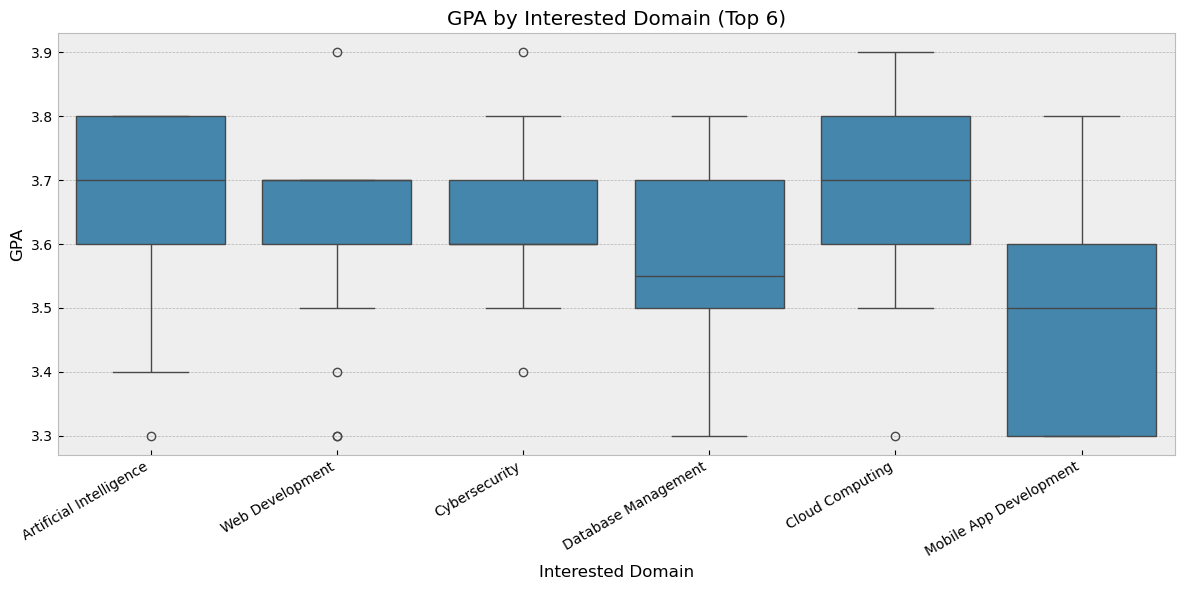

Interested Domain
Artificial Intelligence    3.684211
Cloud Computing            3.681250
Cybersecurity              3.633333
Web Development            3.631579
Database Management        3.575000
Mobile App Development     3.464706
Name: GPA, dtype: float64


In [14]:
top_domains = df['Interested Domain'].value_counts().head(6).index
df_top = df[df['Interested Domain'].isin(top_domains)]

plt.figure(figsize=(12, 6))
ax = sns.boxplot(x='Interested Domain', y='GPA', data=df_top)
plt.setp(ax.artists, alpha=0.5, linewidth=2, edgecolor='k')
plt.xticks(rotation=30, ha='right')
plt.title('GPA by Interested Domain (Top 6)')
plt.tight_layout()
plt.show()

print(df_top.groupby('Interested Domain')['GPA'].mean().sort_values(ascending=False))

### GPA by Future Career (Top 6)

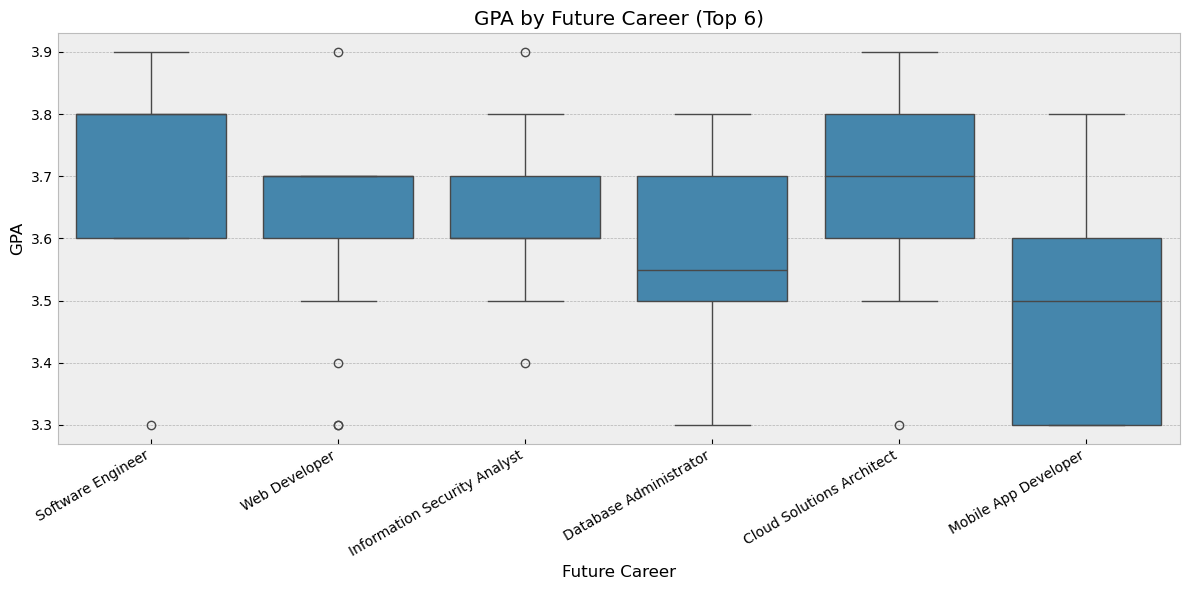

In [15]:
top_careers = df['Future Career'].value_counts().head(6).index
df_careers  = df[df['Future Career'].isin(top_careers)]

plt.figure(figsize=(12, 6))
ax = sns.boxplot(x='Future Career', y='GPA', data=df_careers)
plt.setp(ax.artists, alpha=0.5, linewidth=2, edgecolor='k')
plt.xticks(rotation=30, ha='right')
plt.title('GPA by Future Career (Top 6)')
plt.tight_layout()
plt.show()

### Distribution of Categorical Features

Categorical features to plot: ['Gender', 'Major', 'Interested Domain', 'Future Career']


C:\Users\DELL\AppData\Local\Temp\ipykernel_16316\841400077.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\DELL\AppData\Local\Temp\ipykernel_16316\841400077.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\DELL\AppData\Local\Temp\ipykernel_16316\841400077.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\DELL\AppData\Local\Temp\ipykernel_16316\841400077.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set 

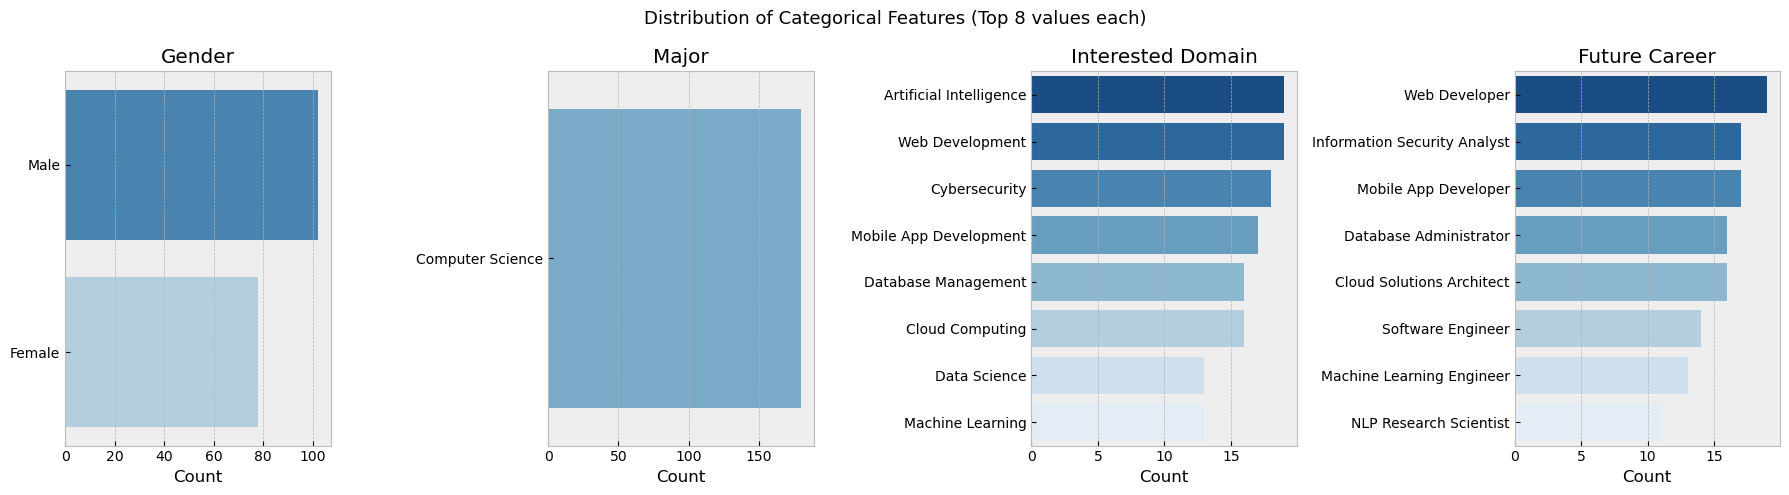

In [16]:
df_not_num = df.select_dtypes(include=['object']).drop(columns=['Name', 'Projects'])
print(f'Categorical features to plot: {df_not_num.columns.tolist()}')

fig, axes = plt.subplots(1, len(df_not_num.columns), figsize=(18, 5))

for i, col in enumerate(df_not_num.columns):
    top_vals = df_not_num[col].value_counts().head(8)
    sns.barplot(
        x=top_vals.values, y=top_vals.index,
        ax=axes[i], palette='Blues_r'
    )
    axes[i].set_title(col)
    axes[i].set_xlabel('Count')
    axes[i].set_ylabel('')

plt.suptitle('Distribution of Categorical Features (Top 8 values each)', fontsize=13)
plt.tight_layout()
plt.show()

**Observations:**
- `Gender` is imbalanced — 102 Males vs 78 Females.
- `Interested Domain` and `Future Career` are highly diverse but the top categories (AI, Web Dev, Cybersecurity) are consistently more represented.
- Many career paths appear only once or twice, making some categories too sparse for modeling.

### Skill Score by Gender

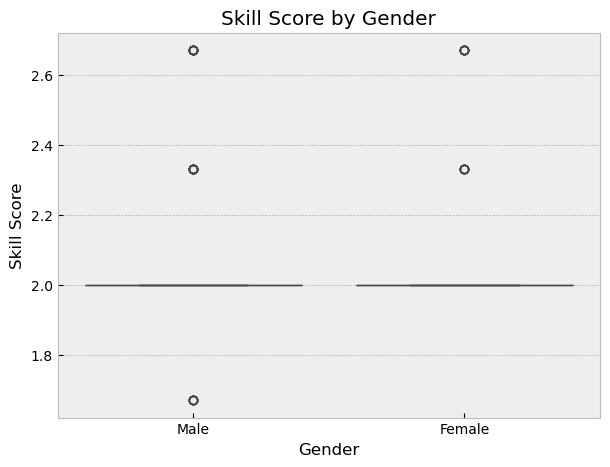

        count      mean       std   min  25%  50%  75%   max
Gender                                                      
Female   78.0  2.098333  0.216203  2.00  2.0  2.0  2.0  2.67
Male    102.0  2.085098  0.242274  1.67  2.0  2.0  2.0  2.67


In [17]:
plt.figure(figsize=(7, 5))
sns.boxplot(x='Gender', y='Skill Score', data=df)
plt.title('Skill Score by Gender')
plt.show()

print(df.groupby('Gender')['Skill Score'].describe())

### Skill Profile by Interested Domain (Top 5)

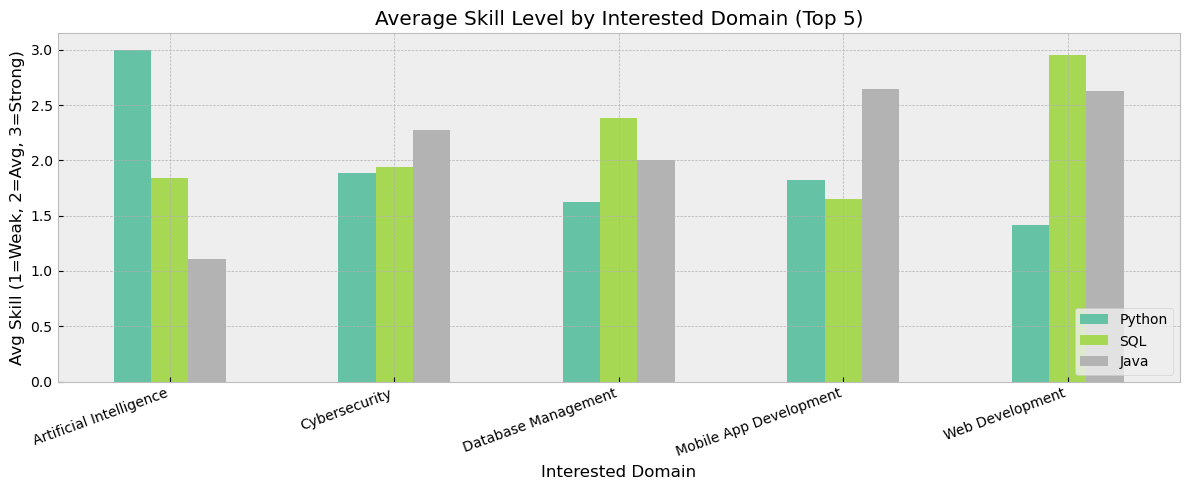

                         Python   SQL  Java
Interested Domain                          
Artificial Intelligence    3.00  1.84  1.11
Cybersecurity              1.89  1.94  2.28
Database Management        1.62  2.38  2.00
Mobile App Development     1.82  1.65  2.65
Web Development            1.42  2.95  2.63


In [18]:
top5_domains = df['Interested Domain'].value_counts().head(5).index
skill_by_domain = (
    df[df['Interested Domain'].isin(top5_domains)]
    .groupby('Interested Domain')[['Python', 'SQL', 'Java']]
    .mean()
    .round(2)
)

skill_by_domain.plot(kind='bar', figsize=(12, 5), colormap='Set2')
plt.title('Average Skill Level by Interested Domain (Top 5)')
plt.ylabel('Avg Skill (1=Weak, 2=Avg, 3=Strong)')
plt.xticks(rotation=20, ha='right')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

print(skill_by_domain)

---

## Summary of EDA Findings

| Finding | Detail |
|---|---|
| GPA distribution | Narrow range (3.2–3.9), slight left skew, most students clustered at 3.5–3.7 |
| Age outliers | Most students are 20–23; a few outliers at 29–37 may need removal |
| Python → GPA | Positive correlation — Python-strong students have higher GPAs |
| Java → GPA | Negative correlation — Java-dominant students tend to have lower GPAs |
| Python vs Java | Strongly negatively correlated — students tend to specialize in one or the other |
| Gender vs GPA | Females have marginally higher median GPA, but difference is minimal |
| Domain → GPA | AI and Cybersecurity students show the highest average GPAs |
| Career diversity | Many career paths are very rare — grouping sparse categories is recommended before modeling |